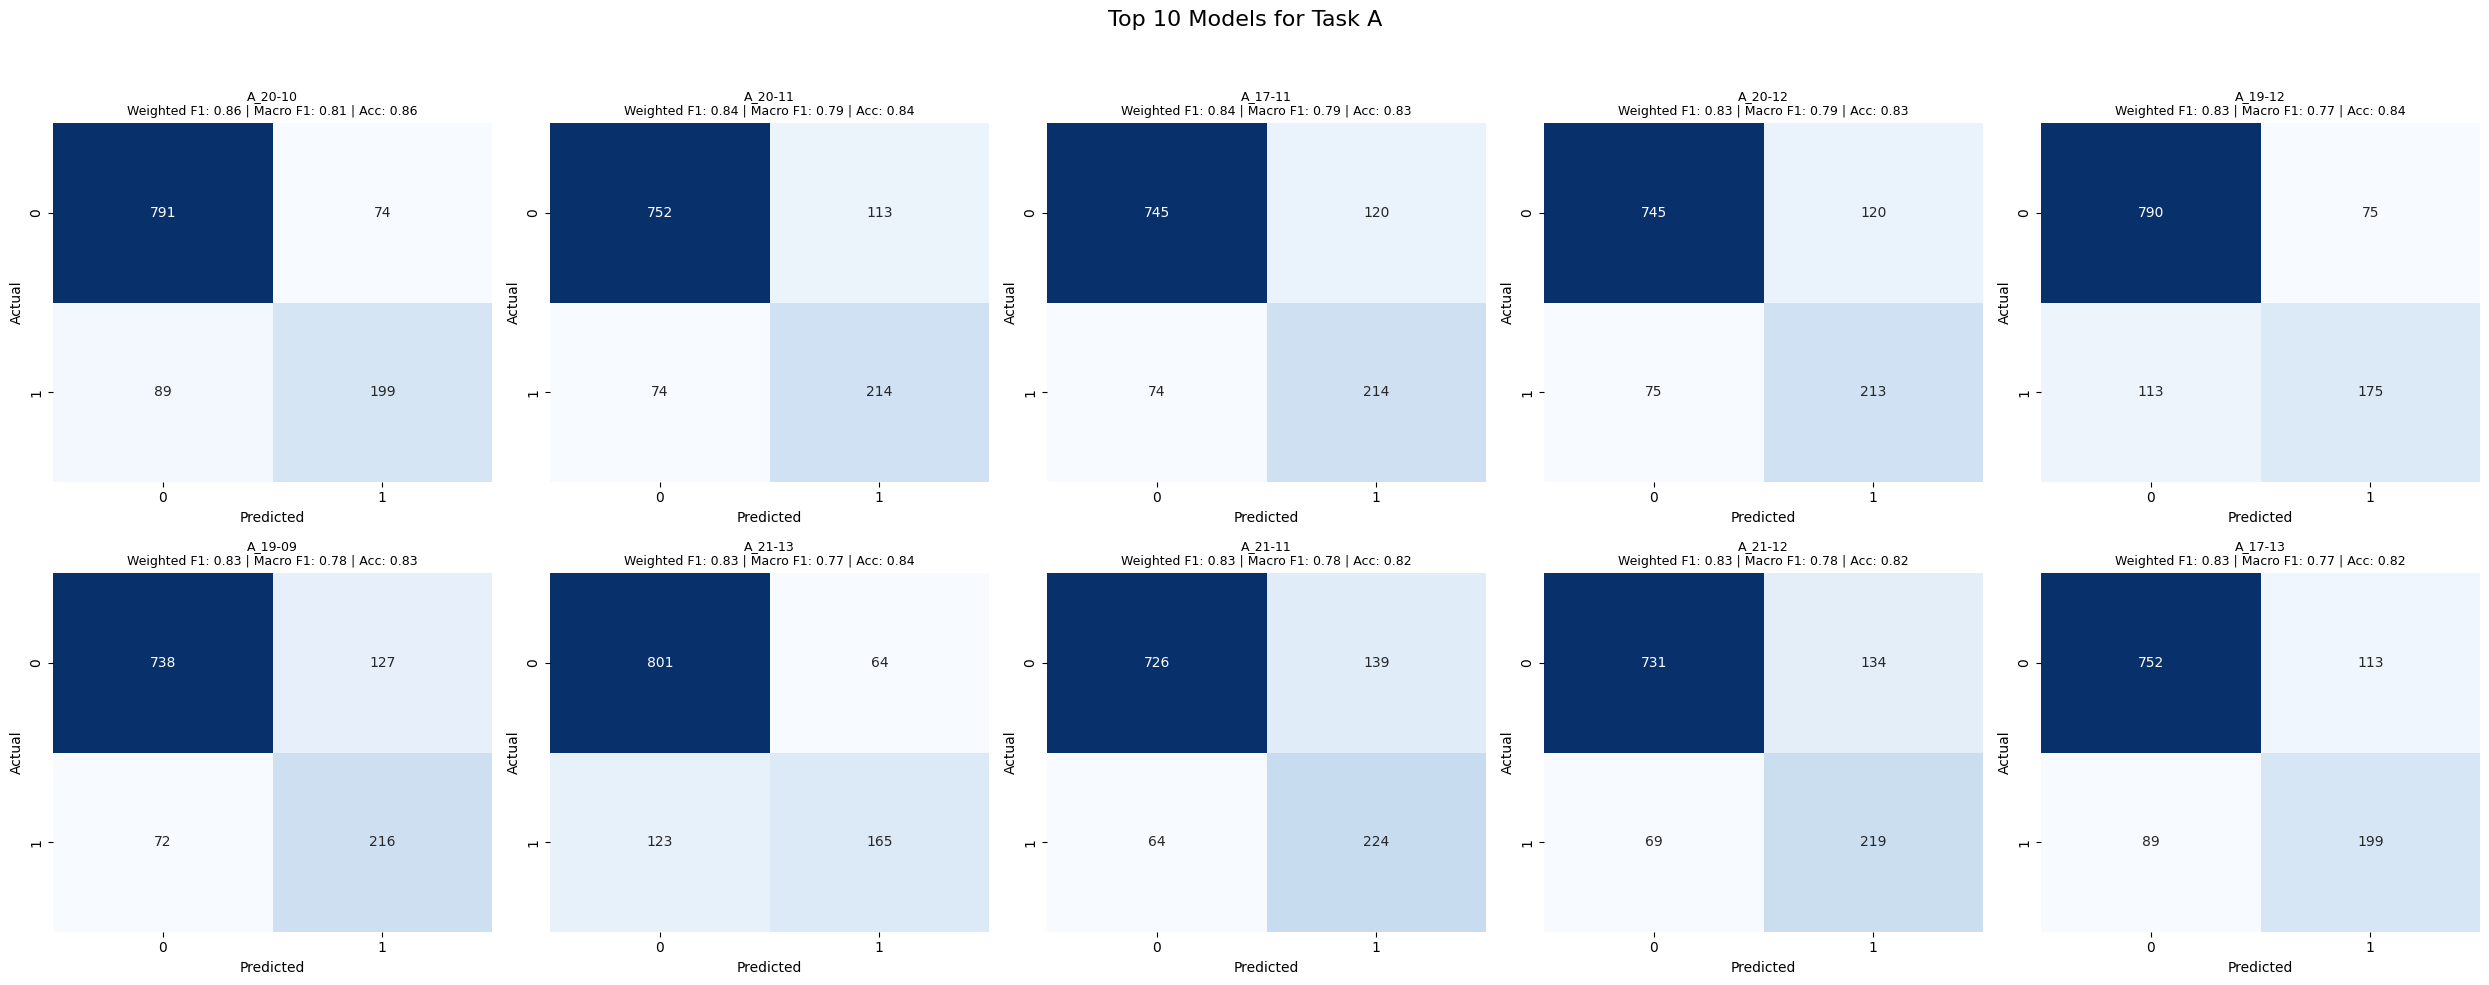

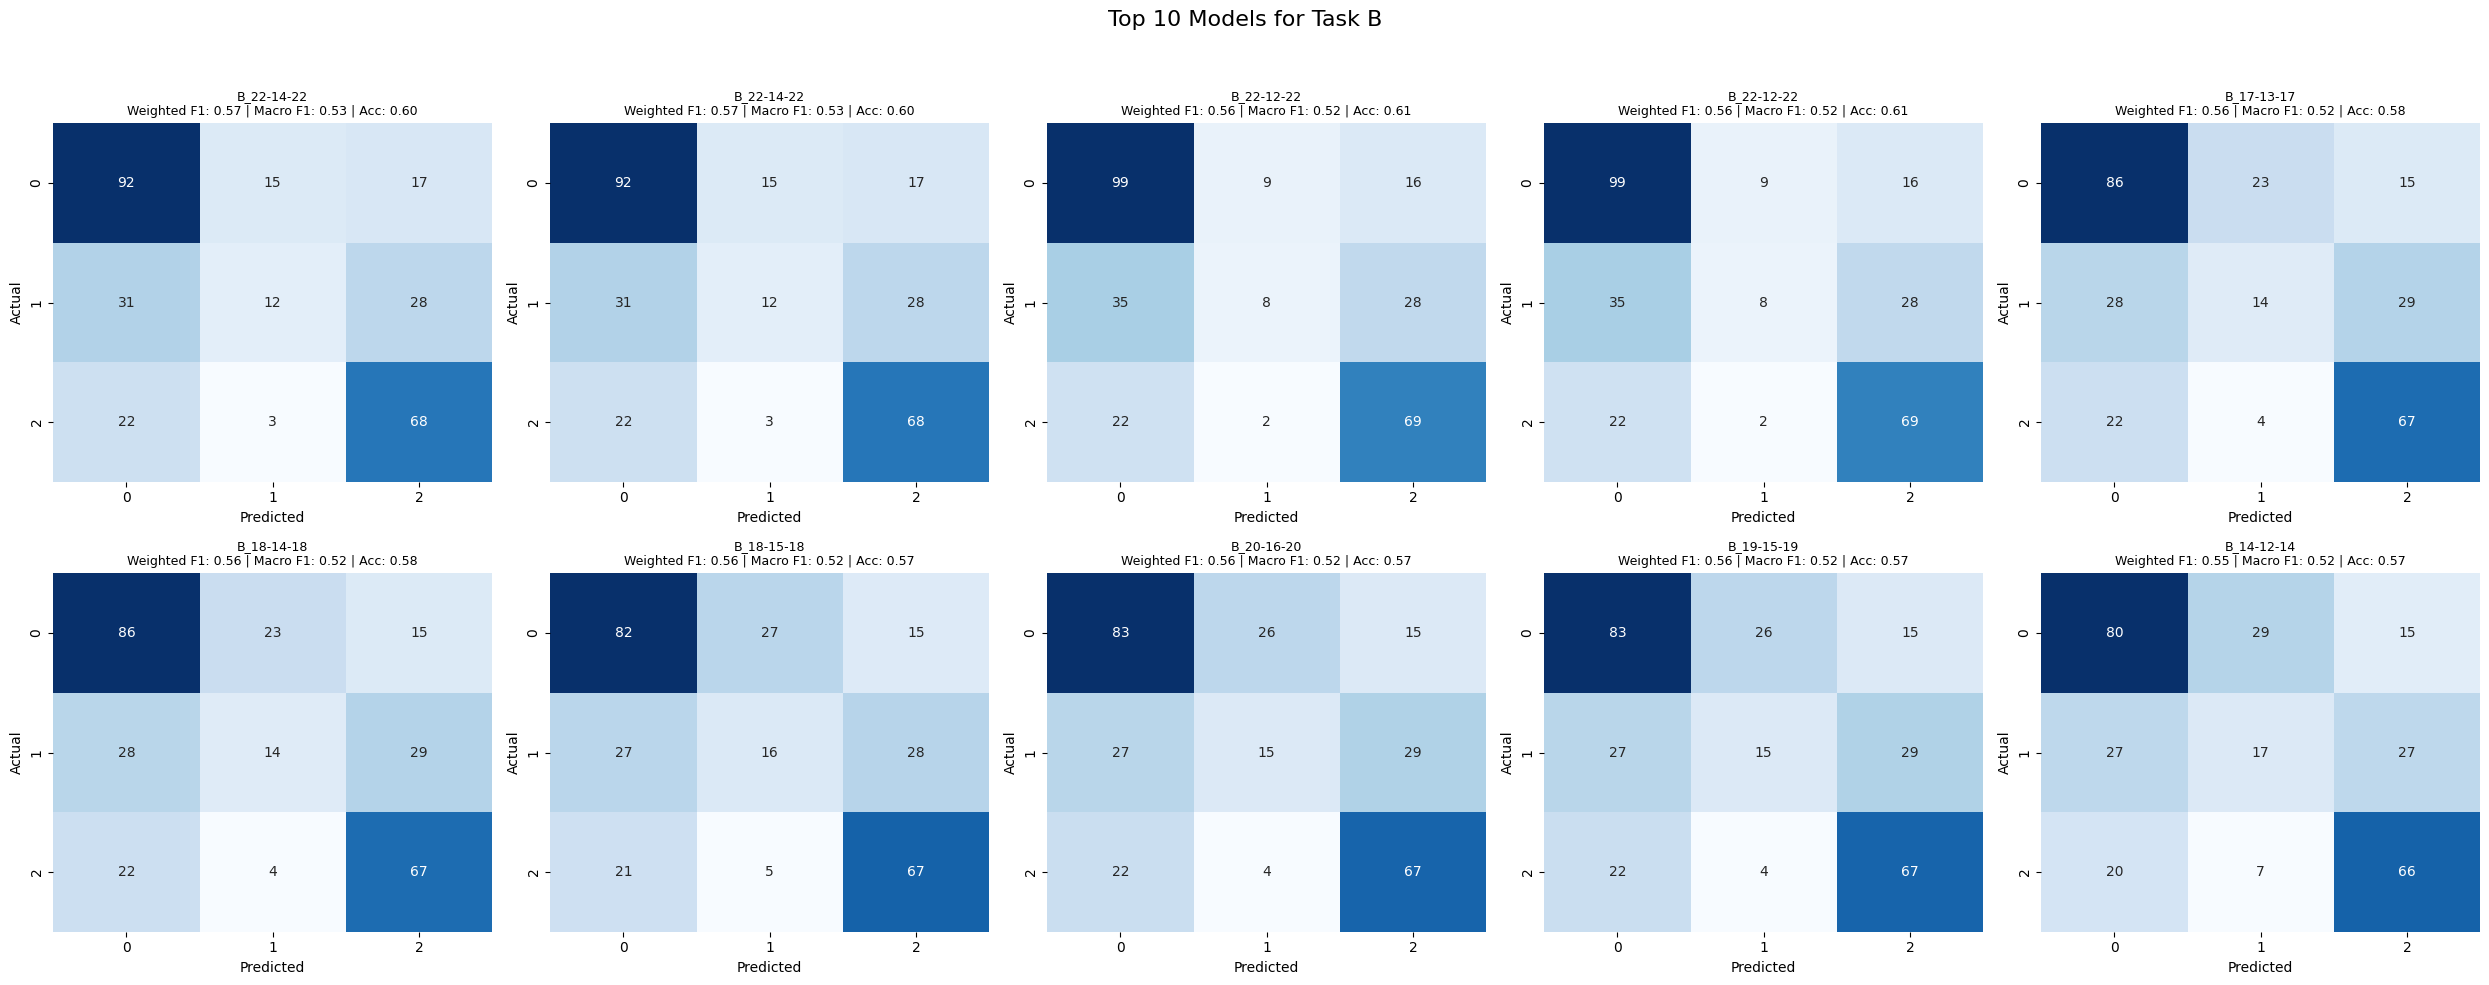

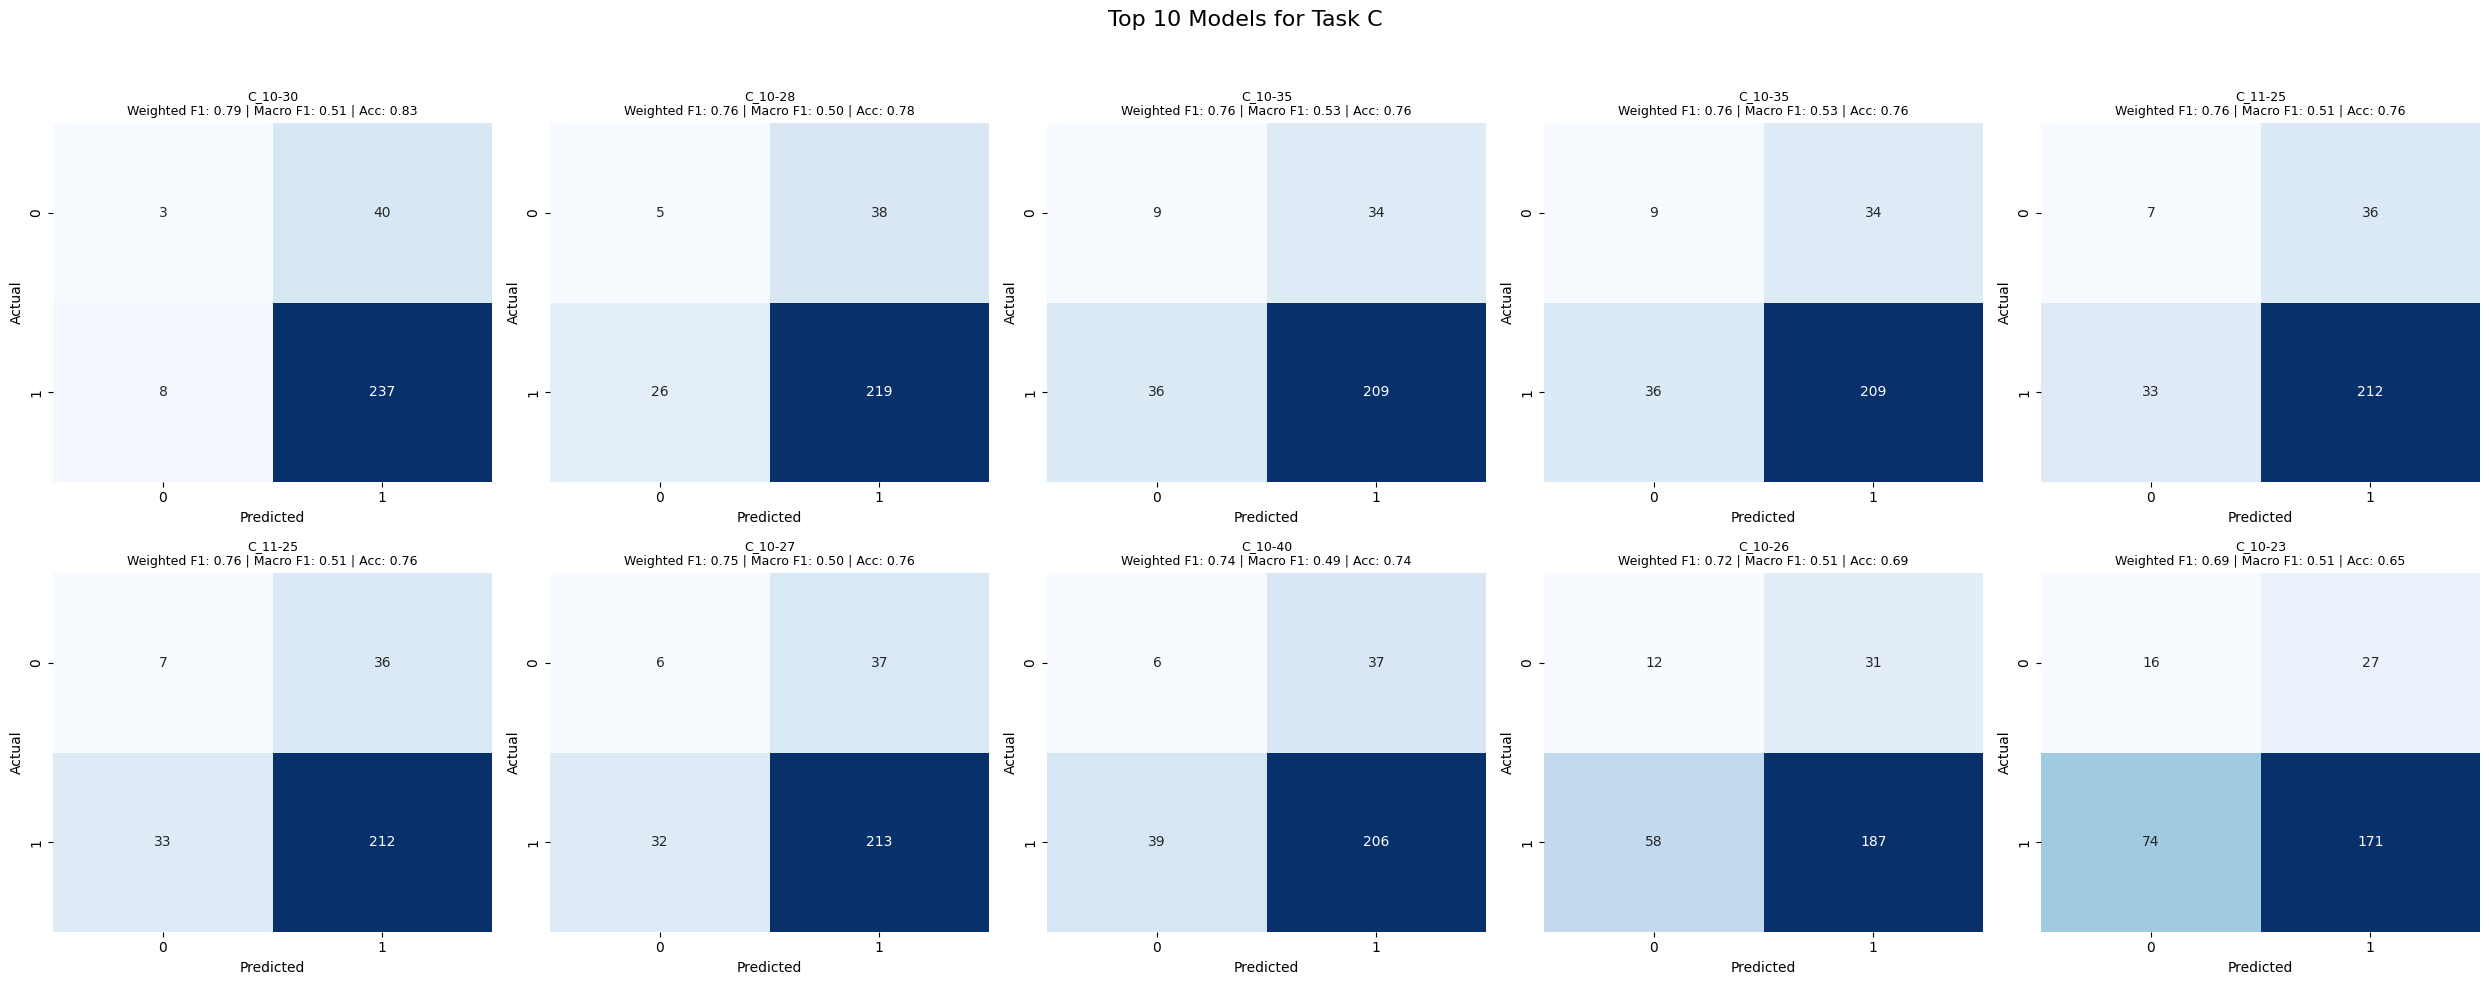

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the summary file
summary_path = "results/grid_metrics/summary_f1_accuracy.csv"
summary = pd.read_csv(summary_path)

# Add path to confusion matrices
summary["confmat_path"] = summary["model_id"].apply(
    lambda mid: f"results/grid_metrics/confmat_{mid}.csv"
)

# Plot a single matrix with metrics
def plot_confmat(ax, matrix, title):
    sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax)
    ax.set_title(title, fontsize=9)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

# For each task, show top 10 models in a 2x5 grid
for task in summary["task"].unique():
    task_df = summary[summary["task"] == task].sort_values(by="f1_weighted", ascending=False).head(10).reset_index(drop=True)
    fig, axes = plt.subplots(2, 5, figsize=(25, 10))
    axes = axes.flatten()
    
    for i, row in task_df.iterrows():
        cm_path = row["confmat_path"]
        if not os.path.exists(cm_path):
            axes[i].axis('off')
            continue
        cm = pd.read_csv(cm_path).values
        title = (
            f"{row['model_id']}\n"
            f"Weighted F1: {row['f1_weighted']:.2f} | "
            f"Macro F1: {row['f1_macro']:.2f} | "
            f"Acc: {row['accuracy']:.2f}"
        )
        plot_confmat(axes[i], cm, title)
    
    # Turn off any unused axes
    for j in range(len(task_df), 10):
        axes[j].axis('off')

    plt.suptitle(f"Top 10 Models for Task {task}", fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()